In [1]:
import ee
import geemap
import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
from google.colab import drive
drive.mount("/content/drive")

PROJECT_ID = "turkiye-border-wellbeing-2026"

ee.Authenticate()
ee.Initialize(project=PROJECT_ID)

print("Earth Engine ready.")

Mounted at /content/drive
Earth Engine ready.


In [3]:
ROOT = Path("/content/drive/MyDrive/turkiye-border-wellbeing")

INTERIM = ROOT / "data/interim"
PROCESSED = ROOT / "data/processed"
RAW_THERMAL = ROOT / "data/raw/lst"
FIGURES = ROOT / "figures/appendix"

RAW_THERMAL.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

In [4]:
grid = gpd.read_file(
    INTERIM / "grid_1km_master.gpkg"
)

grid_wgs84 = grid[
    ["grid_id", "geometry"]
].to_crs("EPSG:4326")

print("Grid cells:", len(grid_wgs84))

Grid cells: 19001


In [5]:
MODIS_LST_ID = "MODIS/061/MOD11A2"

lst = (
    ee.ImageCollection(MODIS_LST_ID)
    .filterDate("2014-01-01", "2026-01-01")
)

print("MODIS LST images:", lst.size().getInfo())

MODIS LST images: 552


In [22]:
def clean_lst(image):

    qc_day = image.select("QC_Day")
    qc_night = image.select("QC_Night")

    # Bits 0-1:
    # 0 = good quality
    # 1 = LST produced, other quality
    # 2-3 = LST not produced / unusable
    good_day = qc_day.bitwiseAnd(3).lte(1)
    good_night = qc_night.bitwiseAnd(3).lte(1)

    day = (
        image.select("LST_Day_1km")
        .multiply(0.02)
        .subtract(273.15)
        .updateMask(good_day)
        .rename("lst_day_c")
    )

    night = (
        image.select("LST_Night_1km")
        .multiply(0.02)
        .subtract(273.15)
        .updateMask(good_night)
        .rename("lst_night_c")
    )

    return (
        ee.Image.cat([day, night])
        .copyProperties(
            image,
            ["system:time_start"]
        )
    )

In [23]:
lst_clean = lst.map(clean_lst)

print(
    ee.Image(lst_clean.first())
    .bandNames()
    .getInfo()
)

['lst_day_c', 'lst_night_c']


In [24]:
def annual_thermal(year):

    year = int(year)

    annual_collection = lst_clean.filterDate(
        f"{year}-01-01",
        f"{year + 1}-01-01"
    )

    summer_collection = lst_clean.filterDate(
        f"{year}-06-01",
        f"{year}-09-01"
    )

    annual_day = (
        annual_collection
        .select("lst_day_c")
        .mean()
        .rename(f"annual_day_{year}")
    )

    annual_night = (
        annual_collection
        .select("lst_night_c")
        .mean()
        .rename(f"annual_night_{year}")
    )

    summer_day = (
        summer_collection
        .select("lst_day_c")
        .mean()
        .rename(f"summer_day_{year}")
    )

    summer_night = (
        summer_collection
        .select("lst_night_c")
        .mean()
        .rename(f"summer_night_{year}")
    )

    return ee.Image.cat([
        annual_day,
        annual_night,
        summer_day,
        summer_night
    ])

In [25]:
filtered_night_2014 = (
    lst_clean
    .filterDate("2014-01-01", "2015-01-01")
    .select("lst_night_c")
    .mean()
)

filtered_check = filtered_night_2014.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=corlu_geom,
    scale=1000,
    bestEffort=True,
    maxPixels=1e7
)

print(
    "Filtered night LST:",
    filtered_check.getInfo()
)

Filtered night LST: {'lst_night_c': 10.641064292779445}


In [26]:
thermal_stack = ee.Image.cat([
    annual_thermal(year)
    for year in range(2014, 2026)
])

print(
    "Band count:",
    len(thermal_stack.bandNames().getInfo())
)

Band count: 48


In [27]:
test_stats = thermal_stack.reduceRegions(
    collection=test_ee,
    reducer=ee.Reducer.mean(),
    scale=1000,
    tileScale=4
)

test_df = geemap.ee_to_df(test_stats)

print("Shape:", test_df.shape)
print(test_df.columns.tolist())

Shape: (500, 49)
['annual_day_2014', 'annual_day_2015', 'annual_day_2016', 'annual_day_2017', 'annual_day_2018', 'annual_day_2019', 'annual_day_2020', 'annual_day_2021', 'annual_day_2022', 'annual_day_2023', 'annual_day_2024', 'annual_day_2025', 'annual_night_2014', 'annual_night_2015', 'annual_night_2016', 'annual_night_2017', 'annual_night_2018', 'annual_night_2019', 'annual_night_2020', 'annual_night_2021', 'annual_night_2022', 'annual_night_2023', 'annual_night_2024', 'annual_night_2025', 'grid_id', 'summer_day_2014', 'summer_day_2015', 'summer_day_2016', 'summer_day_2017', 'summer_day_2018', 'summer_day_2019', 'summer_day_2020', 'summer_day_2021', 'summer_day_2022', 'summer_day_2023', 'summer_day_2024', 'summer_day_2025', 'summer_night_2014', 'summer_night_2015', 'summer_night_2016', 'summer_night_2017', 'summer_night_2018', 'summer_night_2019', 'summer_night_2020', 'summer_night_2021', 'summer_night_2022', 'summer_night_2023', 'summer_night_2024', 'summer_night_2025']


In [28]:
BATCH_SIZE = 500

all_batches = []

for start in range(0, len(grid_wgs84), BATCH_SIZE):

    end = min(start + BATCH_SIZE, len(grid_wgs84))

    print(
        f"Processing grids {start:,}–{end:,} "
        f"of {len(grid_wgs84):,}"
    )

    batch_gdf = (
        grid_wgs84
        .iloc[start:end]
        [["grid_id", "geometry"]]
        .copy()
    )

    batch_ee = geemap.geopandas_to_ee(batch_gdf)

    batch_stats = thermal_stack.reduceRegions(
        collection=batch_ee,
        reducer=ee.Reducer.mean(),
        scale=1000,
        tileScale=4
    )

    batch_df = geemap.ee_to_df(batch_stats)

    all_batches.append(batch_df)

print("All batches completed.")

Processing grids 0–500 of 19,001
Processing grids 500–1,000 of 19,001
Processing grids 1,000–1,500 of 19,001
Processing grids 1,500–2,000 of 19,001
Processing grids 2,000–2,500 of 19,001
Processing grids 2,500–3,000 of 19,001
Processing grids 3,000–3,500 of 19,001
Processing grids 3,500–4,000 of 19,001
Processing grids 4,000–4,500 of 19,001
Processing grids 4,500–5,000 of 19,001
Processing grids 5,000–5,500 of 19,001
Processing grids 5,500–6,000 of 19,001
Processing grids 6,000–6,500 of 19,001
Processing grids 6,500–7,000 of 19,001
Processing grids 7,000–7,500 of 19,001
Processing grids 7,500–8,000 of 19,001
Processing grids 8,000–8,500 of 19,001
Processing grids 8,500–9,000 of 19,001
Processing grids 9,000–9,500 of 19,001
Processing grids 9,500–10,000 of 19,001
Processing grids 10,000–10,500 of 19,001
Processing grids 10,500–11,000 of 19,001
Processing grids 11,000–11,500 of 19,001
Processing grids 11,500–12,000 of 19,001
Processing grids 12,000–12,500 of 19,001
Processing grids 12,50

In [29]:
thermal_wide = pd.concat(
    all_batches,
    ignore_index=True
)

print("Rows:", len(thermal_wide))
print("Columns:", len(thermal_wide.columns))
print("Unique grid IDs:", thermal_wide["grid_id"].nunique())

Rows: 19001
Columns: 49
Unique grid IDs: 19001


In [30]:
annual_day_cols = [f"annual_day_{year}" for year in range(2014, 2026)]
annual_night_cols = [f"annual_night_{year}" for year in range(2014, 2026)]
summer_day_cols = [f"summer_day_{year}" for year in range(2014, 2026)]
summer_night_cols = [f"summer_night_{year}" for year in range(2014, 2026)]

In [31]:
annual_day_long = thermal_wide[
    ["grid_id"] + annual_day_cols
].melt(
    id_vars="grid_id",
    var_name="year",
    value_name="annual_lst_day_c"
)

annual_day_long["year"] = (
    annual_day_long["year"]
    .str.replace("annual_day_", "", regex=False)
    .astype(int)
)

In [32]:
annual_night_long = thermal_wide[
    ["grid_id"] + annual_night_cols
].melt(
    id_vars="grid_id",
    var_name="year",
    value_name="annual_lst_night_c"
)

annual_night_long["year"] = (
    annual_night_long["year"]
    .str.replace("annual_night_", "", regex=False)
    .astype(int)
)

In [33]:
summer_day_long = thermal_wide[
    ["grid_id"] + summer_day_cols
].melt(
    id_vars="grid_id",
    var_name="year",
    value_name="summer_lst_day_c"
)

summer_day_long["year"] = (
    summer_day_long["year"]
    .str.replace("summer_day_", "", regex=False)
    .astype(int)
)

In [34]:
summer_night_long = thermal_wide[
    ["grid_id"] + summer_night_cols
].melt(
    id_vars="grid_id",
    var_name="year",
    value_name="summer_lst_night_c"
)

summer_night_long["year"] = (
    summer_night_long["year"]
    .str.replace("summer_night_", "", regex=False)
    .astype(int)
)

In [35]:
thermal_panel = annual_day_long.merge(
    annual_night_long,
    on=["grid_id", "year"],
    how="left"
).merge(
    summer_day_long,
    on=["grid_id", "year"],
    how="left"
).merge(
    summer_night_long,
    on=["grid_id", "year"],
    how="left"
)

thermal_panel = (
    thermal_panel
    .sort_values(["grid_id", "year"])
    .reset_index(drop=True)
)

print("Panel observations:", len(thermal_panel))
thermal_panel.head(15)

Panel observations: 228012


,grid_id,year,annual_lst_day_c,annual_lst_night_c,summer_lst_day_c,summer_lst_night_c
0,G000001,2014,18.636217,11.310186,26.974608,20.089616
1,G000001,2015,17.756825,10.700294,26.697697,17.787713
2,G000001,2016,18.011171,10.598351,27.491030,19.251293
3,G000001,2017,18.412492,9.597875,28.020237,18.870145
4,G000001,2018,17.846136,11.484773,27.323746,20.228394
5,G000001,2019,18.925762,11.332219,27.935449,20.906236
6,G000001,2020,18.609193,10.581348,27.266677,20.451727
7,G000001,2021,18.832842,9.743911,27.904566,19.899207
8,G000001,2022,18.444616,10.984770,28.090258,20.747898
9,G000001,2023,18.574992,10.871438,27.336813,21.259162


In [36]:
print(
    thermal_panel[
        [
            "annual_lst_day_c",
            "annual_lst_night_c",
            "summer_lst_day_c",
            "summer_lst_night_c"
        ]
    ].describe()
)

       annual_lst_day_c  annual_lst_night_c  summer_lst_day_c  \
count     227772.000000       227762.000000     227772.000000   
mean          21.865326            6.406465         33.333309   
std            2.164273            3.205467          3.611269   
min           13.969730          -12.423205         21.876613   
25%           20.716491            4.345489         31.683308   
50%           22.429404            6.584876         34.390604   
75%           23.440928            8.668314         35.963489   
max           28.340844           20.384730         42.051217   

       summer_lst_night_c  
count       191407.000000  
mean            17.476149  
std              1.960131  
min              4.610000  
25%             16.108831  
50%             17.576261  
75%             18.833309  
max             24.737619  


In [37]:
print("Missing annual day:",
      thermal_panel["annual_lst_day_c"].isna().sum())

print("Missing annual night:",
      thermal_panel["annual_lst_night_c"].isna().sum())

print("Missing summer day:",
      thermal_panel["summer_lst_day_c"].isna().sum())

print("Missing summer night:",
      thermal_panel["summer_lst_night_c"].isna().sum())

Missing annual day: 240
Missing annual night: 250
Missing summer day: 240
Missing summer night: 36605


In [38]:
thermal_qc = (
    thermal_panel
    .groupby("year")
    .agg(
        annual_day_mean=("annual_lst_day_c", "mean"),
        annual_day_median=("annual_lst_day_c", "median"),
        annual_night_mean=("annual_lst_night_c", "mean"),
        annual_night_median=("annual_lst_night_c", "median"),
        summer_day_mean=("summer_lst_day_c", "mean"),
        summer_day_median=("summer_lst_day_c", "median"),
        summer_night_mean=("summer_lst_night_c", "mean"),
        summer_night_median=("summer_lst_night_c", "median")
    )
)

print(thermal_qc)

      annual_day_mean  annual_day_median  annual_night_mean  \
year                                                          
2014        21.719664          22.262772           7.239416   
2015        21.721855          22.424435           6.491508   
2016        22.069136          22.848140           5.315037   
2017        21.967555          22.714277           2.708149   
2018        21.338612          22.025598           7.468673   
2019        22.417269          23.186724           7.647235   
2020        22.776781          23.464294           8.900446   
2021        21.500542          22.087710           5.657974   
2022        22.204197          22.958436           4.859539   
2023        22.497239          23.228405           6.527029   
2024        21.824109          22.578658           8.336595   
2025        20.346954          21.020791           5.725467   

      annual_night_median  summer_day_mean  summer_day_median  \
year                                                

In [39]:
thermal_panel_path = (
    PROCESSED /
    "thermal_grid_year_2014_2025.csv"
)

thermal_panel.to_csv(
    thermal_panel_path,
    index=False
)

print("Saved:", thermal_panel_path)

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/data/processed/thermal_grid_year_2014_2025.csv


In [40]:
thermal_wide_path = (
    INTERIM /
    "thermal_grid_annual_wide_2014_2025.csv"
)

thermal_wide.to_csv(
    thermal_wide_path,
    index=False
)

print("Saved:", thermal_wide_path)

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/data/interim/thermal_grid_annual_wide_2014_2025.csv


In [41]:
thermal_qc_path = (
    INTERIM /
    "thermal_annual_qc_2014_2025.csv"
)

thermal_qc.to_csv(
    thermal_qc_path,
    index_label="year"
)

print("Saved:", thermal_qc_path)

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/data/interim/thermal_annual_qc_2014_2025.csv


In [42]:
import json

thermal_metadata = {
    "dataset": "MODIS/061/MOD11A2",
    "period": "2014-2025",
    "source_temporal_resolution": "8-day",
    "source_spatial_resolution": "1 km",
    "grid_resolution": "1 km x 1 km",
    "variables": [
        "annual_lst_day_c",
        "annual_lst_night_c",
        "summer_lst_day_c",
        "summer_lst_night_c"
    ],
    "units": "degrees Celsius",
    "scale_factor_original": 0.02,
    "quality_filter": "QC bits 0-1 <= 1",
    "annual_aggregation": "Mean of valid MOD11A2 observations",
    "summer_definition": "June-August",
    "grid_count": 19001,
    "panel_observations": 228012
}

metadata_path = (
    INTERIM /
    "thermal_metadata.json"
)

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(
        thermal_metadata,
        f,
        indent=4,
        ensure_ascii=False
    )

print("Saved:", metadata_path)

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/data/interim/thermal_metadata.json


In [43]:
import matplotlib.pyplot as plt

annual_thermal_fig = (
    thermal_panel
    .groupby("year")
    .agg(
        summer_day_mean=("summer_lst_day_c", "mean"),
        summer_day_median=("summer_lst_day_c", "median"),
        summer_night_mean=("summer_lst_night_c", "mean"),
        summer_night_median=("summer_lst_night_c", "median")
    )
    .reset_index()
)

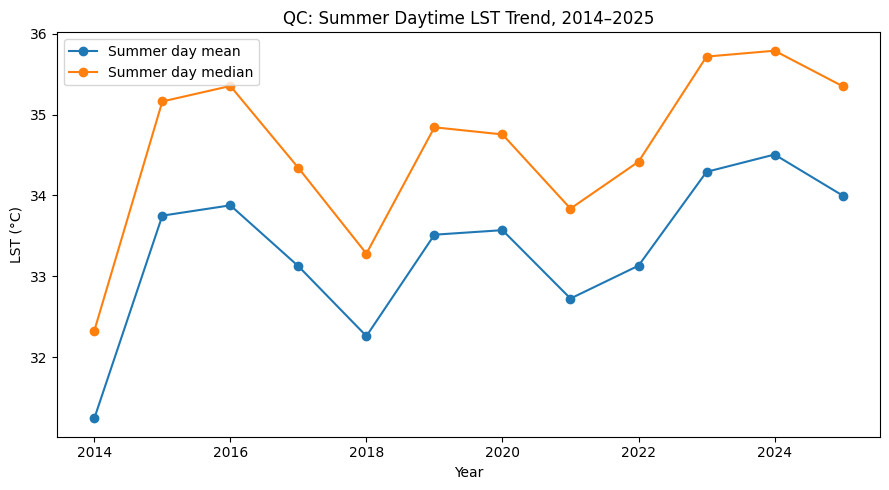

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/figures/appendix/qc_summer_day_lst_trend.png


In [44]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    annual_thermal_fig["year"],
    annual_thermal_fig["summer_day_mean"],
    marker="o",
    label="Summer day mean"
)

ax.plot(
    annual_thermal_fig["year"],
    annual_thermal_fig["summer_day_median"],
    marker="o",
    label="Summer day median"
)

ax.set_xlabel("Year")
ax.set_ylabel("LST (°C)")
ax.set_title("QC: Summer Daytime LST Trend, 2014–2025")
ax.legend()

plt.tight_layout()

out = FIGURES / "qc_summer_day_lst_trend.png"

plt.savefig(
    out,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", out)

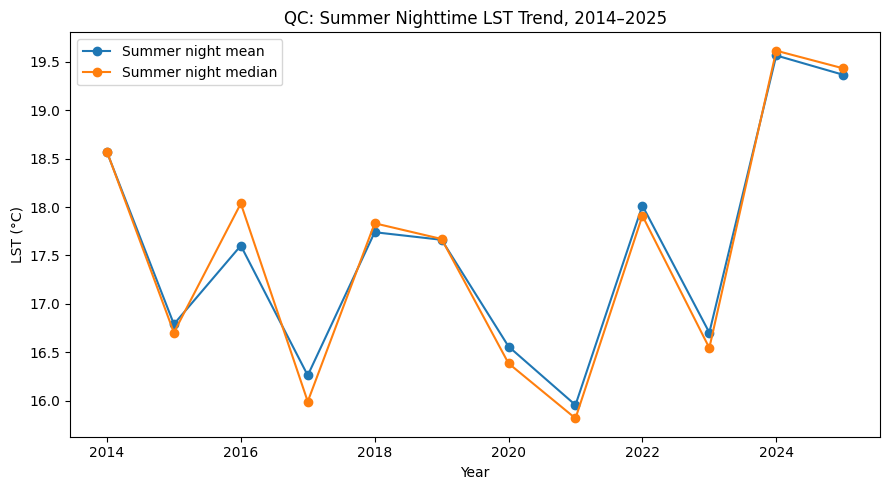

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/figures/appendix/qc_summer_night_lst_trend.png


In [45]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    annual_thermal_fig["year"],
    annual_thermal_fig["summer_night_mean"],
    marker="o",
    label="Summer night mean"
)

ax.plot(
    annual_thermal_fig["year"],
    annual_thermal_fig["summer_night_median"],
    marker="o",
    label="Summer night median"
)

ax.set_xlabel("Year")
ax.set_ylabel("LST (°C)")
ax.set_title("QC: Summer Nighttime LST Trend, 2014–2025")
ax.legend()

plt.tight_layout()

out = FIGURES / "qc_summer_night_lst_trend.png"

plt.savefig(
    out,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", out)